In [1]:
from rag_ingestion_pipeline.models import Document, Chunk

In [2]:
document = Document(
    document_id="doc-001",
    filename="machine_learning.pdf",
    content="Machine learning is a branch of artificial intelligence.",
)

document

Document(document_id='doc-001', filename='machine_learning.pdf', content='Machine learning is a branch of artificial intelligence.')

In [3]:
chunk = Chunk(
    chunk_id="doc-001-chunk-001",
    document_id="doc-001",
    text="Machine learning is a branch of artificail intelligence.",
    chunk_index=0,
    page_number=1,
    strategy="fixed_size",
)

chunk

Chunk(chunk_id='doc-001-chunk-001', document_id='doc-001', text='Machine learning is a branch of artificail intelligence.', chunk_index=0, page_number=1, strategy='fixed_size')

In [4]:
from unittest.mock import Mock
from rag_ingestion_pipeline.ingestion import validate_upload

In [8]:
valid_file = Mock()
valid_file.filename = "machine_learning.pdf"

validate_upload(valid_file, 1_000_000)

In [9]:
invalid_file = Mock()
invalid_file.filename = "malicious.exe"

validate_upload(invalid_file, 1_000_000)

ValueError: Unsupported file type: .exe

In [7]:
large_file = Mock()
large_file.filename = "large_document.pdf"

validate_upload(large_file, 11 * 1024 * 1024)

ValueError: File exceeds the maximum allowed size of 10 MB

In [10]:
txt_file = Mock()
txt_file.filename = "machine_learning.txt"

validate_upload(txt_file, 500_000)


In [11]:
from rag_ingestion_pipeline.ingestion import extract_text_from_pdf
from pathlib import Path

In [12]:
pdf_path = Path(r"C:\Users\michaelfa\Downloads\MLT.pdf")
pdf_content = pdf_path.read_bytes()
pages = extract_text_from_pdf(pdf_content)
pages[:2]

[(1,
  'MICROSOFT LEARN  October 2023 \n \nPL-300T00 Power BI Data Analyst \n          1 \n \nSection 1: Learning path questions \nIntroduction \nThis section includes multiple choice and/or open-ended questions that are aligned to the course learning paths \nfor PL-300T00 Power BI Data Analyst.  \nYou can use the questions as they are presented or modify them as appropriate for your learners. The questions do \nnot appear in any other course materials and are designed to supplement the formative assessment opportunities \nthat are integrated directly into Microsoft Learn and the Microsoft Official Course, such as Knowledge Checks, “Try-\nIt” activities, Exercises, Walkthroughs, Labs, and Demos.  \nQuestions are designed to allow for easy integration into an online quiz through Microsoft Forms or through your \ninstitution’s Learning Management System (LMS). If you aren’t familiar with the Microsoft Forms short support \nvideos are available. As a best practice, create new quizzes and 

In [13]:
from rag_ingestion_pipeline.ingestion import extract_document

In [14]:
document_pages = extract_document(pdf_content, "MLT.pdf")

document_pages[:2]

[(1,
  'MICROSOFT LEARN  October 2023 \n \nPL-300T00 Power BI Data Analyst \n          1 \n \nSection 1: Learning path questions \nIntroduction \nThis section includes multiple choice and/or open-ended questions that are aligned to the course learning paths \nfor PL-300T00 Power BI Data Analyst.  \nYou can use the questions as they are presented or modify them as appropriate for your learners. The questions do \nnot appear in any other course materials and are designed to supplement the formative assessment opportunities \nthat are integrated directly into Microsoft Learn and the Microsoft Official Course, such as Knowledge Checks, “Try-\nIt” activities, Exercises, Walkthroughs, Labs, and Demos.  \nQuestions are designed to allow for easy integration into an online quiz through Microsoft Forms or through your \ninstitution’s Learning Management System (LMS). If you aren’t familiar with the Microsoft Forms short support \nvideos are available. As a best practice, create new quizzes and 

In [15]:
txt_content = b"Machine learning is a branch of artificial intelligence."

document_text = extract_document(txt_content, "machine_learning.txt")

document_text

[(None, 'Machine learning is a branch of artificial intelligence.')]

In [16]:
from rag_ingestion_pipeline.chunking import fixed_size_chunk

chunks = fixed_size_chunk(
    document_id="mlt-001",
    pages=document_pages,
    chunk_size=500,
    overlap=50,
)

len(chunks)

101

In [17]:
chunks[0]

Chunk(chunk_id='mlt-001-chunk-001', document_id='mlt-001', text='MICROSOFT LEARN  October 2023 \n \nPL-300T00 Power BI Data Analyst \n          1 \n \nSection 1: Learning path questions \nIntroduction \nThis section includes multiple choice and/or open-ended questions that are aligned to the course learning paths \nfor PL-300T00 Power BI Data Analyst.  \nYou can use the questions as they are presented or modify them as appropriate for your learners. The questions do \nnot appear in any other course materials and are designed to supplement the formative assessment oppor', chunk_index=0, page_number=1, strategy='fixed_size')

In [18]:
chunks[1]

Chunk(chunk_id='mlt-001-chunk-002', document_id='mlt-001', text='igned to supplement the formative assessment opportunities \nthat are integrated directly into Microsoft Learn and the Microsoft Official Course, such as Knowledge Checks, “Try-\nIt” activities, Exercises, Walkthroughs, Labs, and Demos.  \nQuestions are designed to allow for easy integration into an online quiz through Microsoft Forms or through your \ninstitution’s Learning Management System (LMS). If you aren’t familiar with the Microsoft Forms short support \nvideos are available. As a best practi', chunk_index=1, page_number=1, strategy='fixed_size')

In [32]:
chunks[100]

Chunk(chunk_id='mlt-001-chunk-101', document_id='mlt-001', text='e the dynamic method uses a DAX function.) \n ', chunk_index=100, page_number=23, strategy='fixed_size')

In [19]:
from rag_ingestion_pipeline.chunking import fixed_size_chunk

# Test that overlap cannot be equal to or greater than chunk size.
fixed_size_chunk(
    document_id="test-001",
    pages=[(1, "This is a test document.")],
    chunk_size=100,
    overlap=100,
)

ValueError: Overlap must be smaller than chunk size

In [20]:
from rag_ingestion_pipeline.chunking import paragraph_chunk

paragraph_chunks = paragraph_chunk(
    document_id="mlt-001",
    pages=document_pages,
)

len(paragraph_chunks)

23

In [21]:
paragraph_chunks[0]

Chunk(chunk_id='mlt-001-chunk-001', document_id='mlt-001', text='MICROSOFT LEARN  October 2023 \n \nPL-300T00 Power BI Data Analyst \n          1 \n \nSection 1: Learning path questions \nIntroduction \nThis section includes multiple choice and/or open-ended questions that are aligned to the course learning paths \nfor PL-300T00 Power BI Data Analyst.  \nYou can use the questions as they are presented or modify them as appropriate for your learners. The questions do \nnot appear in any other course materials and are designed to supplement the formative assessment opportunities \nthat are integrated directly into Microsoft Learn and the Microsoft Official Course, such as Knowledge Checks, “Try-\nIt” activities, Exercises, Walkthroughs, Labs, and Demos.  \nQuestions are designed to allow for easy integration into an online quiz through Microsoft Forms or through your \ninstitution’s Learning Management System (LMS). If you aren’t familiar with the Microsoft Forms short support \nvideos a

In [22]:
# Calculate the character length of each chunk.
fixed_lengths = [len(chunk.text) for chunk in chunks]
paragraph_lengths = [len(chunk.text) for chunk in paragraph_chunks]

# Display basic size statistics for both strategies.
print("Fixed-size:")
print("Minimum:", min(fixed_lengths))
print("Maximum:", max(fixed_lengths))
print("Average:", sum(fixed_lengths) / len(fixed_lengths))

print("\nParagraph:")
print("Minimum:", min(paragraph_lengths))
print("Maximum:", max(paragraph_lengths))
print("Average:", sum(paragraph_lengths) / len(paragraph_lengths))

Fixed-size:
Minimum: 20
Maximum: 500
Average: 438.7524752475247

Paragraph:
Minimum: 1019
Maximum: 2762
Average: 1755.6521739130435


In [23]:
# Find the largest paragraph-based chunk.
largest_paragraph = max(
    paragraph_chunks,
    key=lambda chunk: len(chunk.text),
)

print("Chunk ID:", largest_paragraph.chunk_id)
print("Page:", largest_paragraph.page_number)
print("Character count:", len(largest_paragraph.text))
print("Strategy:", largest_paragraph.strategy)

Chunk ID: mlt-001-chunk-015
Page: 15
Character count: 2762
Strategy: paragraph


In [24]:
print(largest_paragraph.text[:1000])

MICROSOFT LEARN  October 2023 
 
PL-300T00 Power BI Data Analyst 
          15 
5. Can you use bookmarks to create a slide show in Power BI? 
Select the correct option. 
a.   No, you cannot, because bookmarks are not dynamic. 
b.   Yes, you can. (correct answer) 
c.    No, you will require a specific visual to achieve this task. 
Open-ended questions 
1. When designing a report layout, what should you consider before building the report? 
Answer: (Should include a statement that includes choose the correct format, consider the audience 
of your report, consider the different needs that the end user may have, and consider the visuals 
and elements needed.) 
2. Power BI has a variety of visuals that you can use to report on the data in your data model. Visuals allow you to 
present the important information and insights that you discovered in the data in a compelling and insightful way. 
What should you consider when adding visuals to a report? 
Answer: (Should include a statement that i

In [25]:
# Compare the two chunking strategies using the measurements we collected.
comparison = {
    "Fixed-size": {
        "Number of chunks": len(chunks),
        "Minimum characters": min(fixed_lengths),
        "Maximum characters": max(fixed_lengths),
        "Average characters": round(sum(fixed_lengths) / len(fixed_lengths), 2),
        "Overlap": "50 characters",
    },
    "Paragraph": {
        "Number of chunks": len(paragraph_chunks),
        "Minimum characters": min(paragraph_lengths),
        "Maximum characters": max(paragraph_lengths),
        "Average characters": round(
            sum(paragraph_lengths) / len(paragraph_lengths), 2
        ),
        "Overlap": "None",
    },
}

comparison

{'Fixed-size': {'Number of chunks': 101,
  'Minimum characters': 20,
  'Maximum characters': 500,
  'Average characters': 438.75,
  'Overlap': '50 characters'},
 'Paragraph': {'Number of chunks': 23,
  'Minimum characters': 1019,
  'Maximum characters': 2762,
  'Average characters': 1755.65,
  'Overlap': 'None'}}

In [26]:
import pandas as pd

# Convert the comparison dictionary into a readable DataFrame.
comparison_df = pd.DataFrame(comparison).T

comparison_df

,Number of chunks,Minimum characters,Maximum characters,Average characters,Overlap
Fixed-size,101,20,500,438.75,50 characters
Paragraph,23,1019,2762,1755.65,None


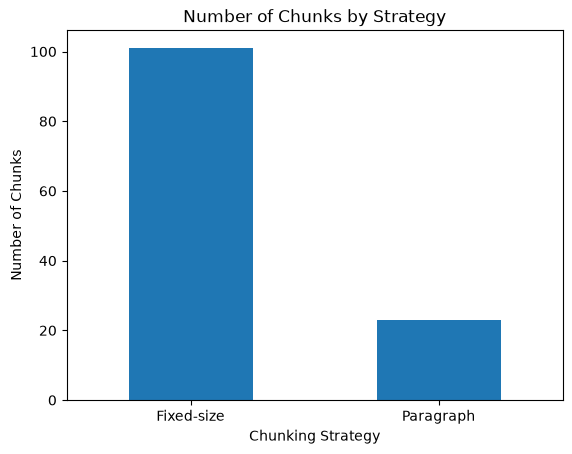

In [27]:
import matplotlib.pyplot as plt

# Plot the number of chunks produced by each strategy.
comparison_df["Number of chunks"].plot(
    kind="bar",
    title="Number of Chunks by Strategy",
)

plt.xlabel("Chunking Strategy")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=0)
plt.show()

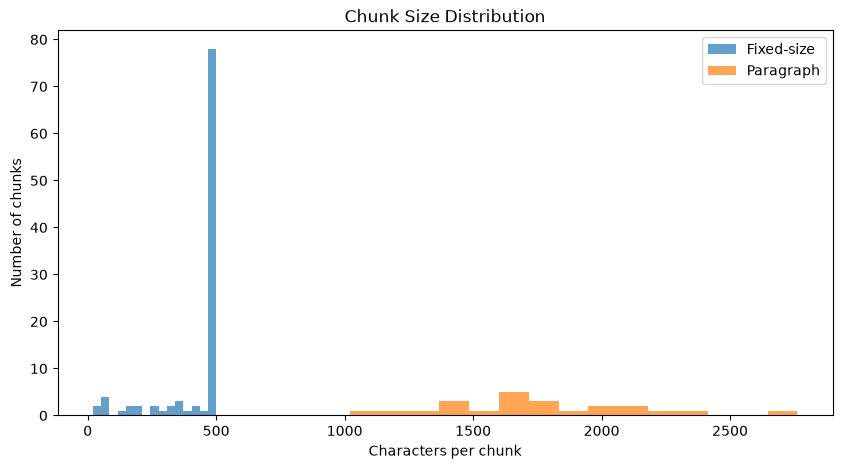

In [28]:
# Plot the distribution of chunk sizes for both strategies.
plt.figure(figsize=(10, 5))

plt.hist(
    fixed_lengths,
    bins=15,
    alpha=0.7,
    label="Fixed-size",
)

plt.hist(
    paragraph_lengths,
    bins=15,
    alpha=0.7,
    label="Paragraph",
)

plt.title("Chunk Size Distribution")
plt.xlabel("Characters per chunk")
plt.ylabel("Number of chunks")
plt.legend()

plt.show()

## Chunking Strategy Comparison

Two chunking strategies were implemented and tested using the same PDF document:

1. Fixed-size chunking with 500-character chunks and 50-character overlap.
2. Paragraph-based chunking without overlap.

### Results

| Metric | Fixed-size | Paragraph |
|---|---:|---:|
| Number of chunks | 101 | 23 |
| Minimum characters | 20 | 1,019 |
| Maximum characters | 500 | 2,762 |
| Average characters | 438.75 | 1,755.65 |
| Overlap | 50 characters | None |

### Decision

Fixed-size chunking with 500-character chunks and 50-character overlap was selected as the primary chunking strategy.

The fixed-size approach provides more consistent chunk sizes and produces smaller retrieval units. The overlap helps preserve context between adjacent chunks. The paragraph strategy preserves larger blocks of text, but some chunks were substantially larger and contained multiple questions or concepts, which could reduce retrieval precision.

A limitation of fixed-size chunking is that it can split sentences or ideas across chunk boundaries. The 50-character overlap helps reduce this problem, but does not eliminate it completely.